In [ ]:
import pandas as pd

# Zeek conn.log field names, taken from the #fields header line of the file
COLS = ["ts","uid","id.orig_h","id.orig_p","id.resp_h","id.resp_p","proto","service",
        "duration","orig_bytes","resp_bytes","conn_state","local_orig","local_resp",
        "missed_bytes","history","orig_pkts","orig_ip_bytes","resp_pkts","resp_ip_bytes",
        "tunnel_parents","label","det_label"]

# The file is tab-separated. Lines starting with '#' are Zeek metadata, not data.
# Zeek writes '-' for unset fields and '(empty)' for empty ones.
df = pd.read_csv("conn.log.labeled.txt",
                 sep="\t", comment="#", names=COLS,
                 na_values=["-","(empty)"], low_memory=False)

print("Rows and columns:", df.shape)
df.head()

Rows and columns: (23145, 23)


,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,...,local_resp,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents,label,det_label
0,1.545404e+09,CrDn63WjJEmrWGjqf,192.168.1.195,41040,185.244.25.235,80,tcp,NaN,3.139211,0.0,...,NaN,0,S,3,180,0,0,NaN,Benign,NaN
1,1.545404e+09,CY9lJW3gh1Eje4usP6,192.168.1.195,41040,185.244.25.235,80,tcp,NaN,NaN,NaN,...,NaN,0,S,1,60,0,0,NaN,Benign,NaN
2,1.545404e+09,CcFXLynukEDnUlvgl,192.168.1.195,41040,185.244.25.235,80,tcp,NaN,NaN,NaN,...,NaN,0,S,1,60,0,0,NaN,Benign,NaN
3,1.545404e+09,CDrkrSobGYxHhYfth,192.168.1.195,41040,185.244.25.235,80,tcp,http,1.477656,149.0,...,NaN,2896,ShADadttcfF,94,5525,96,139044,NaN,Benign,NaN
4,1.545404e+09,CTWZQf2oJSvq6zmPAc,192.168.1.195,41042,185.244.25.235,80,tcp,NaN,3.147116,0.0,...,NaN,0,S,3,180,0,0,NaN,Benign,NaN


In [ ]:
# General structure of the dataset: column types and memory usage
df.info()

# Count and percentage of missing values per column
print("\n--- Missing values per column ---")
missing = pd.DataFrame({
    "missing": df.isna().sum(),
    "percent": (df.isna().sum() / len(df) * 100).round(2)
})
print(missing[missing["missing"] > 0].sort_values("percent", ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23145 entries, 0 to 23144
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ts              23145 non-null  float64
 1   uid             23145 non-null  object 
 2   id.orig_h       23145 non-null  object 
 3   id.orig_p       23145 non-null  int64  
 4   id.resp_h       23145 non-null  object 
 5   id.resp_p       23145 non-null  int64  
 6   proto           23145 non-null  object 
 7   service         1847 non-null   object 
 8   duration        5321 non-null   float64
 9   orig_bytes      5321 non-null   float64
 10  resp_bytes      5321 non-null   float64
 11  conn_state      23145 non-null  object 
 12  local_orig      0 non-null      float64
 13  local_resp      0 non-null      float64
 14  missed_bytes    23145 non-null  int64  
 15  history         23145 non-null  object 
 16  orig_pkts       23145 non-null  int64  
 17  orig_ip_bytes   23145 non-null 

In [ ]:
# Work on a copy so the original load stays intact
clean = df.copy()

# 1. Drop columns that are empty in every single row
empty_cols = ["local_orig", "local_resp", "tunnel_parents"]
clean = clean.drop(columns=empty_cols)

# 2. Drop the unique flow identifier: useful for tracing, not for analysis
clean = clean.drop(columns=["uid"])

# 3. Benign traffic has no attack sub-label, so the gap is not a real missing value
clean["det_label"] = clean["det_label"].fillna("Benign")

# 4. Zeek could not identify the application protocol in most flows.
#    Mark it explicitly instead of leaving it as NaN.
clean["service"] = clean["service"].fillna("unknown")

# 5. Convert the Unix timestamp into a readable datetime
clean["ts"] = pd.to_datetime(clean["ts"], unit="s")

print("Before:", df.shape)
print("After: ", clean.shape)
print("\n--- Remaining missing values ---")
print(clean.isna().sum()[clean.isna().sum() > 0])

Before: (23145, 23)
After:  (23145, 19)

--- Remaining missing values ---
duration      17824
orig_bytes    17824
resp_bytes    17824
dtype: int64


In [ ]:
# Flag the rows where Zeek could not record duration or byte counts
clean["incomplete"] = clean["duration"].isna()

# Is the missingness related to the connection state?
print("--- conn_state vs incomplete records ---")
print(pd.crosstab(clean["conn_state"], clean["incomplete"]))

# And is it related to the type of traffic?
print("\n--- Percentage of incomplete records by traffic type ---")
print((pd.crosstab(clean["det_label"], clean["incomplete"], normalize="index") * 100).round(1))

--- conn_state vs incomplete records ---
incomplete  False  True 
conn_state              
OTH             0  14260
RSTR           53      0
S0           2831   3564
S1              4      0
S3           1584      0
SF            849      0

--- Percentage of incomplete records by traffic type ---
incomplete                 False  True 
det_label                              
Benign                      52.2   47.8
C&C                         64.0   36.0
DDoS                         0.1   99.9
PartOfAHorizontalPortScan    9.0   91.0


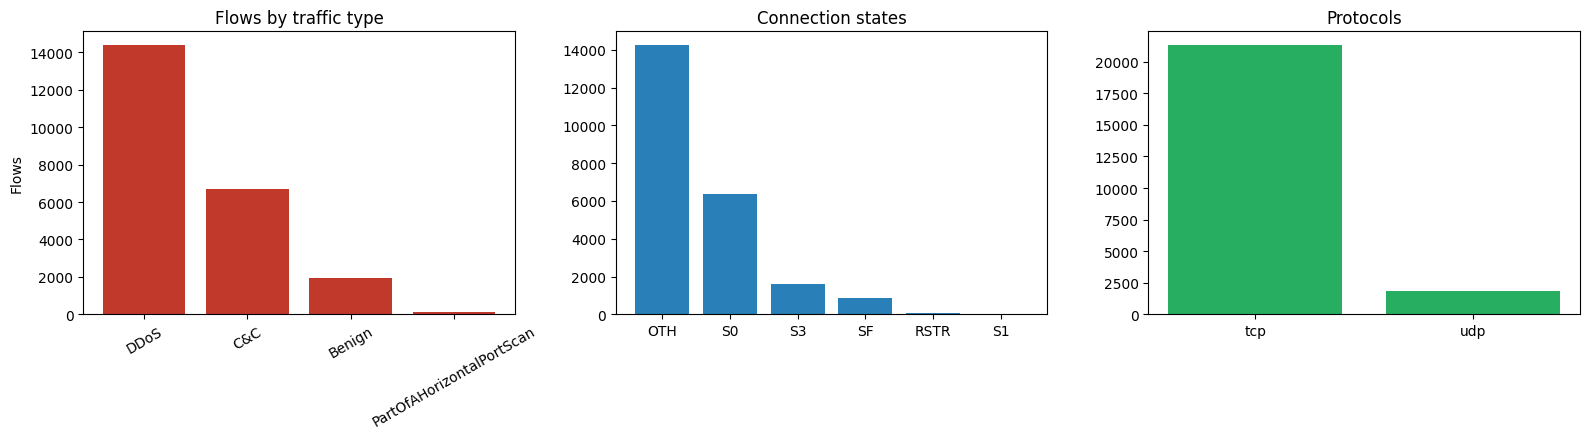

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. How many flows of each traffic type
counts = clean["det_label"].value_counts()
axes[0].bar(counts.index, counts.values, color="#c0392b")
axes[0].set_title("Flows by traffic type")
axes[0].set_ylabel("Flows")
axes[0].tick_params(axis="x", rotation=30)

# 2. Connection states: incomplete connections dominate
states = clean["conn_state"].value_counts()
axes[1].bar(states.index, states.values, color="#2980b9")
axes[1].set_title("Connection states")

# 3. Protocols used
protos = clean["proto"].value_counts()
axes[2].bar(protos.index, protos.values, color="#27ae60")
axes[2].set_title("Protocols")

plt.tight_layout()
plt.show()